In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
import time
import os
from datetime import datetime, timedelta
from collections import defaultdict, deque

warnings.filterwarnings("ignore")
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/sample_submission.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/test_identity.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_identity.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/test_transaction.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_transaction.csv


In [2]:
df_raw = pd.read_csv("/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_transaction.csv")

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [4]:
numeric_cols_raw = df_raw.select_dtypes(include=["int64", "float64"]).columns
object_cols_raw = df_raw.select_dtypes(include="object").columns

print(f"\nTotal Rows       : {df_raw.shape[0]:,}")
print(f"Total Columns    : {df_raw.shape[1]:,}")
print(f"Numeric Columns  : {len(numeric_cols_raw)}")
print(f"Categorical Cols : {len(object_cols_raw)}")
print("\nData Type Distribution:")
print(df_raw.dtypes.value_counts())
df_raw.describe()


Total Rows       : 590,540
Total Columns    : 394
Numeric Columns  : 380
Categorical Cols : 14

Data Type Distribution:
float64    376
object      14
int64        4
Name: count, dtype: int64


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,0.000000,0.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,55.000000,160000.000000,160000.000000,160000.000000,55125.000000,55125.00000,55125.000000,104060.000000,104060.000000,104060.000000



isFraud counts:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud Rate : 3.4990%
Imbalance  : 1 fraud per 27 legit txn


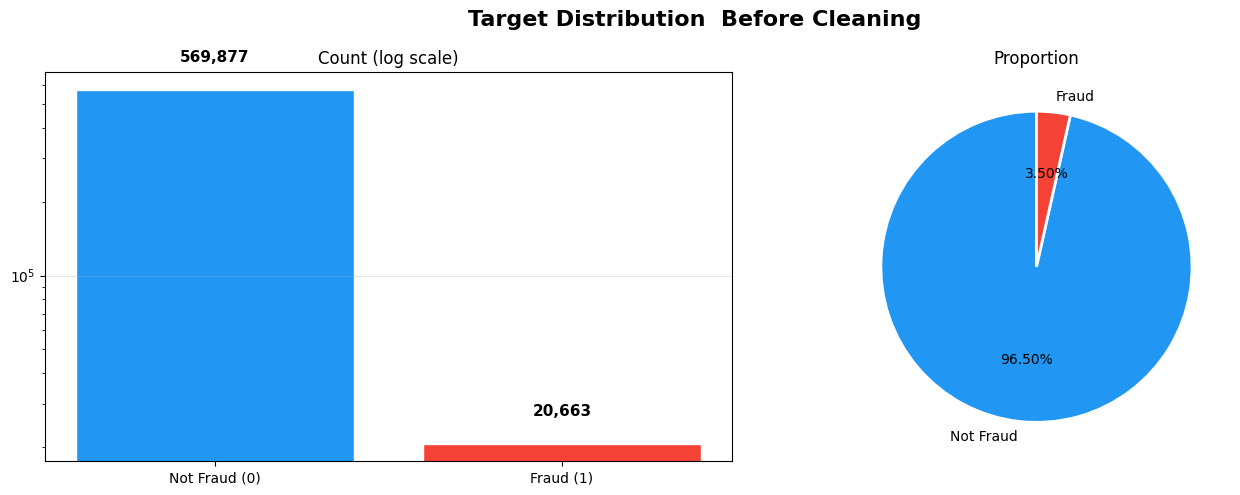

In [5]:
fraud_counts = df_raw["isFraud"].value_counts()
fraud_rate   = df_raw["isFraud"].mean() * 100

print(f"\nisFraud counts:\n{fraud_counts}")
print(f"\nFraud Rate : {fraud_rate:.4f}%")
print(f"Imbalance  : 1 fraud per {int(fraud_counts[0]/fraud_counts[1])} legit txn")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Target Distribution  Before Cleaning", fontsize=16, fontweight="bold")
colors = ["#2196F3", "#F44336"]

bars = axes[0].bar(["Not Fraud (0)", "Fraud (1)"],
                   fraud_counts.values, color=colors, edgecolor="white")
axes[0].set_title("Count (log scale)"); axes[0].set_yscale("log")
for bar, cnt in zip(bars, fraud_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.3,
                 f"{cnt:,}", ha="center", fontsize=11, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

axes[1].pie(fraud_counts.values, labels=["Not Fraud","Fraud"],
            autopct="%1.2f%%", colors=colors, startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Proportion")
plt.tight_layout(); plt.show()

In [6]:
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_ratio = df_raw.isnull().mean().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "count": missing,
    "ratio": missing_ratio
}).query("count > 0")

print(f"Missing Coloumns: {len(missing_df)}")
print(missing_df.head(20))

Missing Coloumns: 374
        count     ratio
dist2  552913  0.936284
D7     551623  0.934099
D13    528588  0.895093
D14    528353  0.894695
D12    525823  0.890410
D6     517353  0.876068
D8     515614  0.873123
D9     515614  0.873123
V162   508595  0.861237
V142   508595  0.861237
V146   508595  0.861237
V147   508595  0.861237
V141   508595  0.861237
V138   508595  0.861237
V163   508595  0.861237
V161   508595  0.861237
V154   508595  0.861237
V153   508595  0.861237
V158   508595  0.861237
V157   508595  0.861237


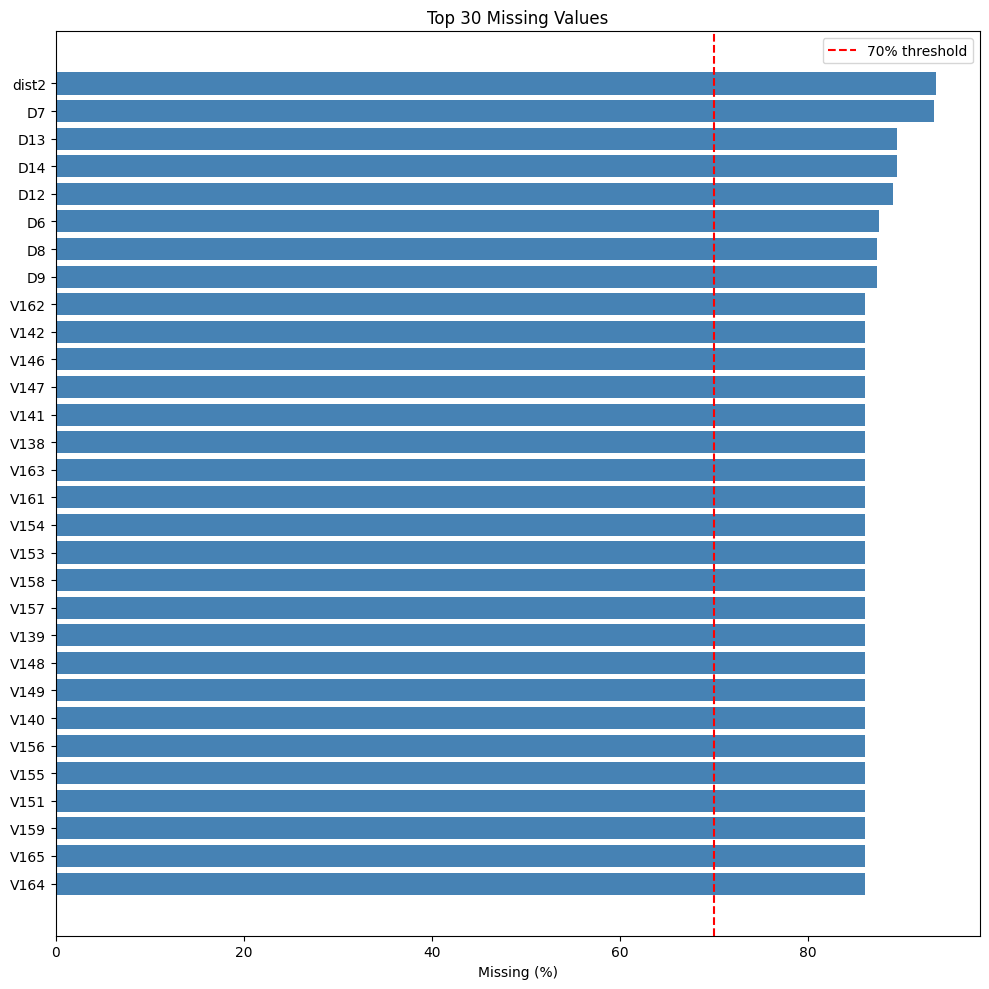

In [7]:
top30 = missing_df.head(30)

plt.figure(figsize=(10, 10))
plt.barh(top30.index[::-1], top30["ratio"][::-1] * 100, color="steelblue")
plt.axvline(x=70, color="red", linestyle="--", label="70% threshold")
plt.xlabel("Missing (%)")
plt.title("Top 30 Missing Values")
plt.legend()
plt.tight_layout()
plt.show()

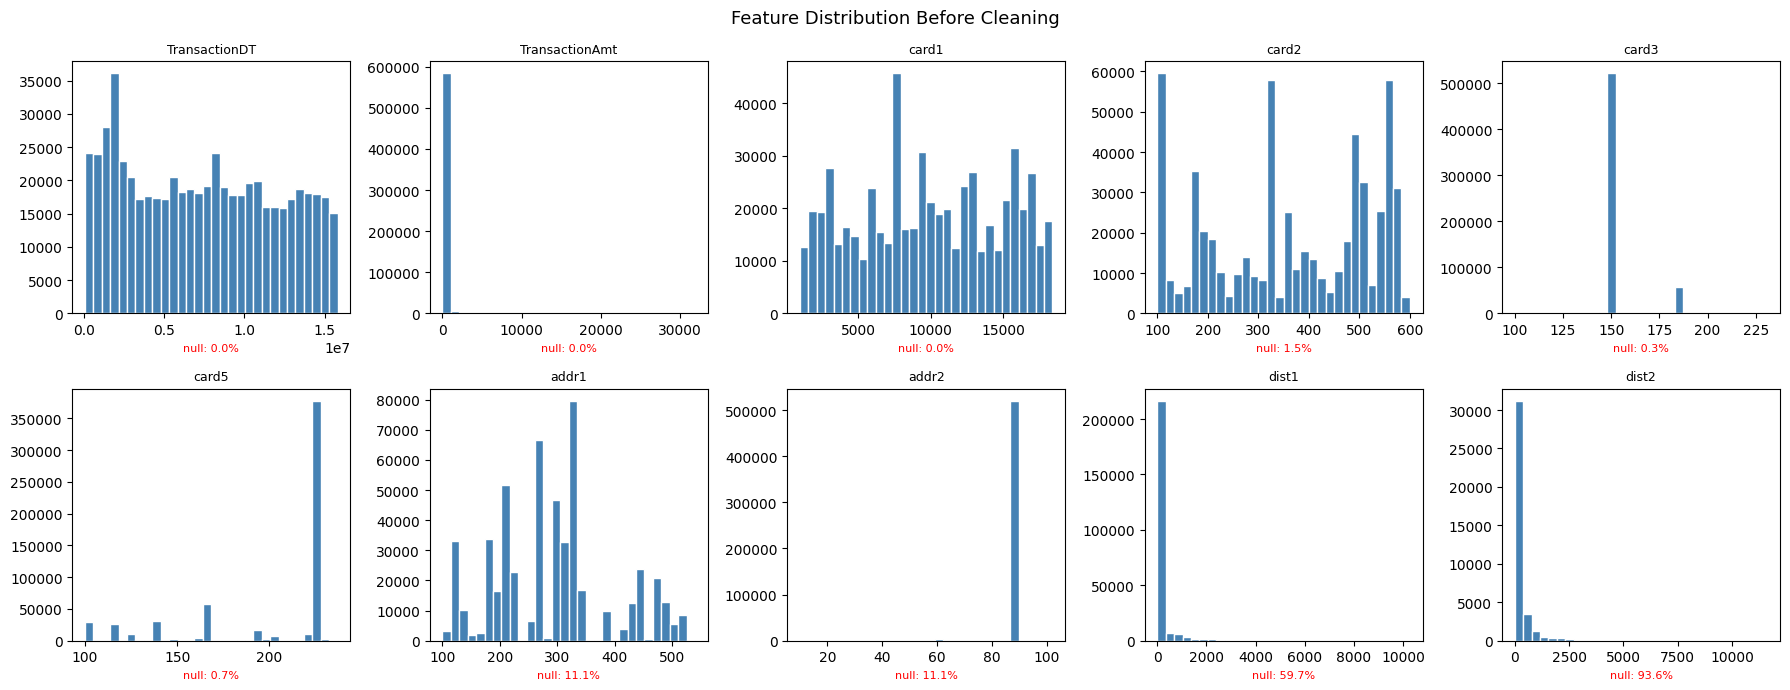

In [8]:
num_sample = [c for c in numeric_cols_raw if c not in ["isFraud", "TransactionID"]][:10]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_sample):
    axes[i].hist(df_raw[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(col, fontsize=9)
    null_pct = df_raw[col].isnull().mean() * 100
    axes[i].set_xlabel(f"null: {null_pct:.1f}%", fontsize=8, color="red")

plt.suptitle("Feature Distribution Before Cleaning", fontsize=13)
plt.tight_layout()
plt.show()

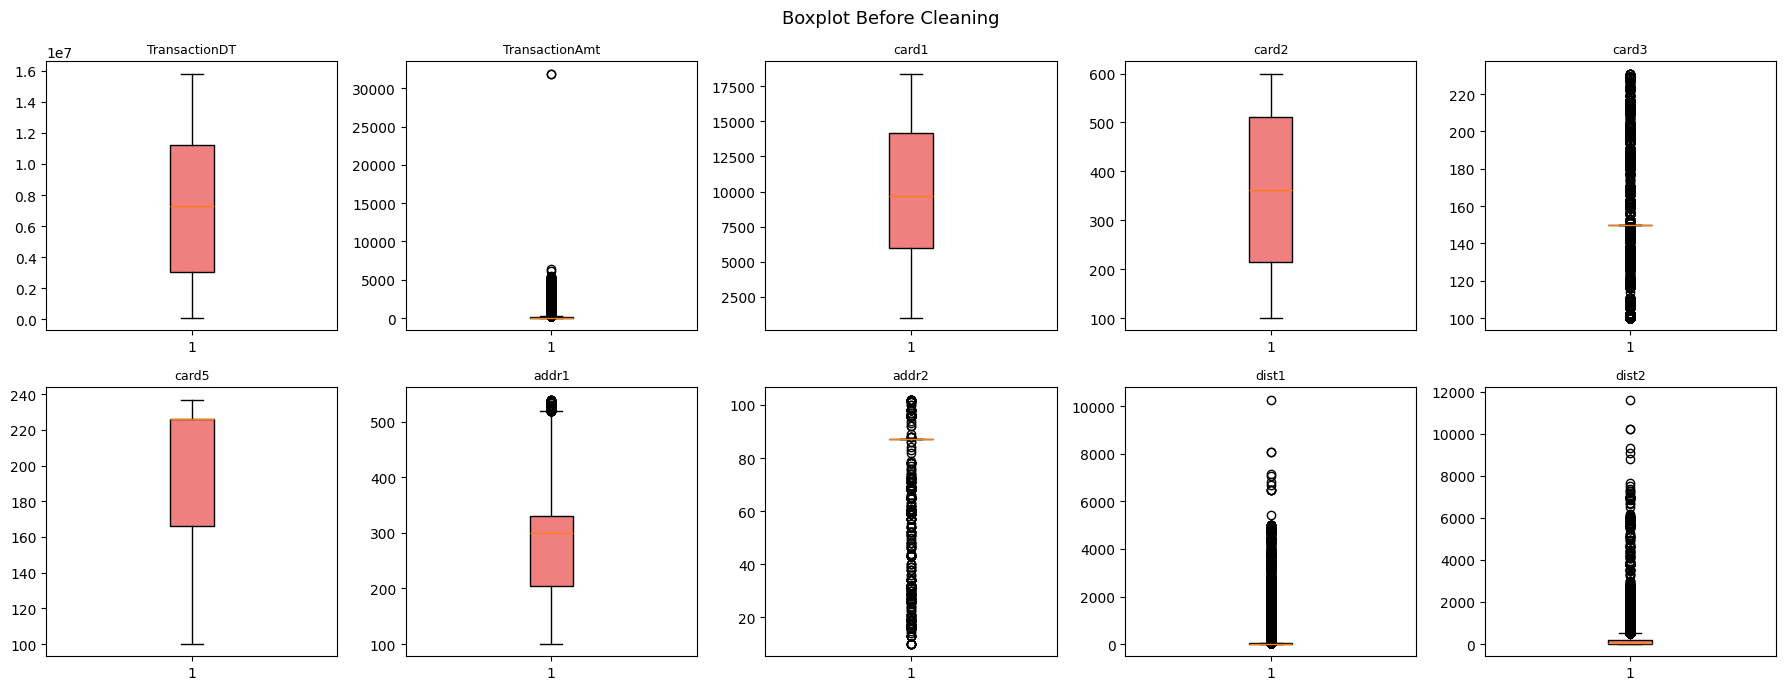

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_sample):
    axes[i].boxplot(df_raw[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor="lightcoral"))
    axes[i].set_title(col, fontsize=9)

plt.suptitle("Boxplot Before Cleaning", fontsize=13)
plt.tight_layout()
plt.show()

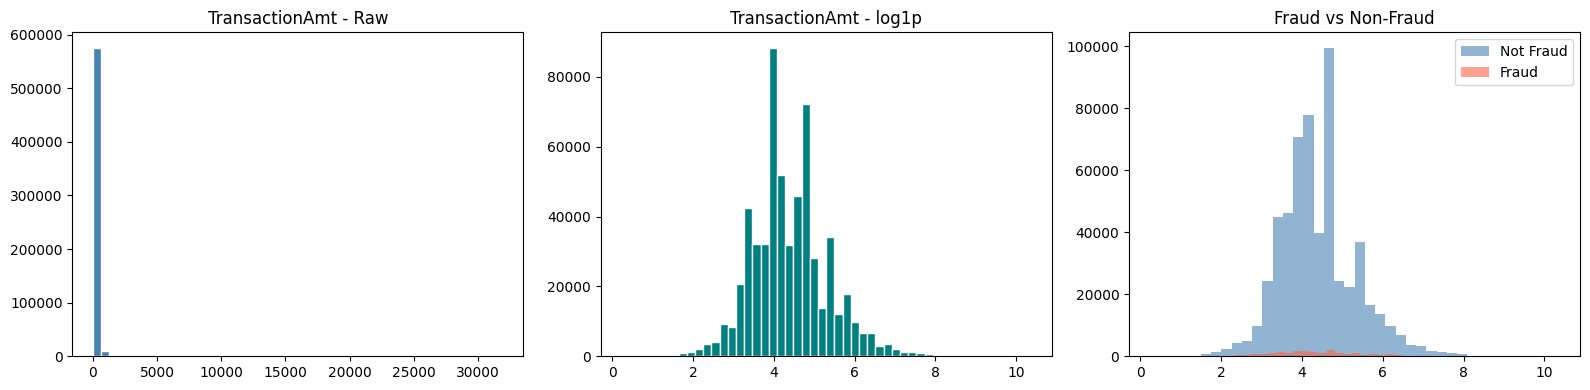

            count        mean         std    min     25%   50%    75%  \
isFraud                                                                 
0        569877.0  134.511665  239.395078  0.251  43.970  68.5  120.0   
1         20663.0  149.244779  232.212163  0.292  35.044  75.0  161.0   

               max  
isFraud             
0        31937.391  
1         5191.000  


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_raw["TransactionAmt"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("TransactionAmt - Raw")

axes[1].hist(np.log1p(df_raw["TransactionAmt"].dropna()), bins=50, color="teal", edgecolor="white")
axes[1].set_title("TransactionAmt - log1p")

for lbl, clr, nm in [(0, "steelblue", "Not Fraud"), (1, "tomato", "Fraud")]:
    d = df_raw[df_raw["isFraud"] == lbl]["TransactionAmt"].dropna()
    axes[2].hist(np.log1p(d), bins=40, alpha=0.6, color=clr, label=nm)
axes[2].set_title("Fraud vs Non-Fraud")
axes[2].legend()

plt.tight_layout()
plt.show()

print(df_raw.groupby("isFraud")["TransactionAmt"].describe())

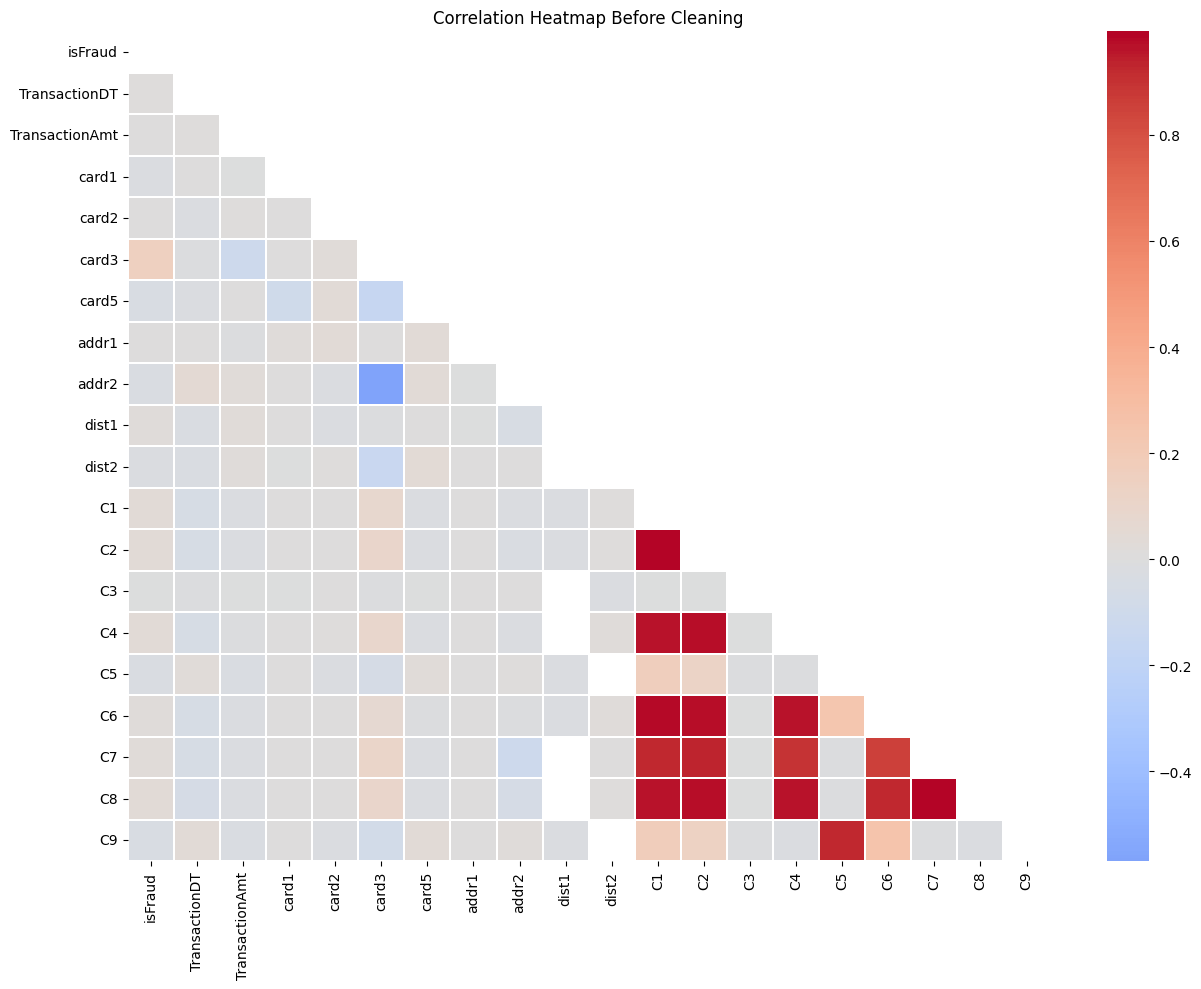

In [11]:
corr_cols = [c for c in numeric_cols_raw if c != "TransactionID"][:20]

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones(len(corr_cols), dtype=bool))
sns.heatmap(df_raw[corr_cols].corr(), mask=mask, cmap="coolwarm",
            center=0, linewidths=0.3)
plt.title("Correlation Heatmap Before Cleaning")
plt.tight_layout()
plt.show()

In [12]:
# -- STEP 1: FEATURE SELECTION ----------------------------------------------
# Keep only the 13 features exposed in the web app's manual fraud-check form.
# All V*, C*, D*, M*, id_* columns and anything not in the list are dropped.

FEATURES_13 = [
    'TransactionDT', 'TransactionAmt',
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'ProductCD', 'addr1', 'addr2',
    'P_emaildomain', 'R_emaildomain',
]

df = df_raw[FEATURES_13 + ['isFraud']].copy()

print(f'Shape after 13-feature selection: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()


Shape after 13-feature selection: (590540, 14)
Columns: ['TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'ProductCD', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'isFraud']


,TransactionDT,TransactionAmt,card1,card2,card3,card4,card5,card6,ProductCD,addr1,addr2,P_emaildomain,R_emaildomain,isFraud
0,86400,68.5,13926,NaN,150.0,discover,142.0,credit,W,315.0,87.0,NaN,NaN,0
1,86401,29.0,2755,404.0,150.0,mastercard,102.0,credit,W,325.0,87.0,gmail.com,NaN,0
2,86469,59.0,4663,490.0,150.0,visa,166.0,debit,W,330.0,87.0,outlook.com,NaN,0
3,86499,50.0,18132,567.0,150.0,mastercard,117.0,debit,W,476.0,87.0,yahoo.com,NaN,0
4,86506,50.0,4497,514.0,150.0,mastercard,102.0,credit,H,420.0,87.0,gmail.com,NaN,0


In [13]:
# TransactionID is not part of the 13-feature set; no additional drop needed.
# This cell is intentionally left as a pass to preserve downstream cell numbering.
pass


In [14]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
object_cols = df.select_dtypes(include="object").columns.tolist()

print("numeric:", len(numeric_cols))
print("categorical:", len(object_cols))

numeric: 9
categorical: 5


In [15]:
# -- STEP 2: CATEGORICAL ENCODING --------------------------------------------
# Use fixed, interpretable integer maps for the 5 categorical features so that
# the web application can replicate the same encoding without a stored encoder.

# card4  : payment network
card4_map = {'visa': 1, 'mastercard': 2, 'american express': 3, 'discover': 4}
df['card4'] = df['card4'].str.lower().str.strip().map(card4_map)

# card6  : account type
card6_map = {'credit': 1, 'debit': 2}
df['card6'] = df['card6'].str.lower().str.strip().map(card6_map)

# ProductCD : product category
productcd_map = {'W': 1, 'H': 2, 'C': 3, 'S': 4, 'R': 5}
df['ProductCD'] = df['ProductCD'].str.strip().map(productcd_map)

# P_emaildomain / R_emaildomain : frequency-anchored domain encoding.
# Common domains get a known integer; rare/unknown domains default to 50.
email_map = {
    'gmail.com':    16,
    'yahoo.com':    11,
    'outlook.com':   3,
    'hotmail.com':  25,
    'anonymous.com': 50,
}

def encode_email(series, mapping, default=50):
    """Map known domains; anything else (incl. NaN) -> default."""
    return series.str.lower().str.strip().map(mapping).fillna(default)

df['P_emaildomain'] = encode_email(df['P_emaildomain'], email_map)
df['R_emaildomain'] = encode_email(df['R_emaildomain'], email_map)

# -- STEP 3: NaN HANDLING -----------------------------------------------------
# Fill any remaining NaN values (unmapped categoricals, missing numerics) with 0.
df = df.fillna(0)

print('Encoding complete.')
print(f'Remaining NaN: {df.isnull().sum().sum()}')
print('\nDtype summary after encoding:')
print(df.dtypes)
df.head()


Encoding complete.
Remaining NaN: 0

Dtype summary after encoding:
TransactionDT       int64
TransactionAmt    float64
card1               int64
card2             float64
card3             float64
card4             float64
card5             float64
card6             float64
ProductCD           int64
addr1             float64
addr2             float64
P_emaildomain     float64
R_emaildomain     float64
isFraud             int64
dtype: object


,TransactionDT,TransactionAmt,card1,card2,card3,card4,card5,card6,ProductCD,addr1,addr2,P_emaildomain,R_emaildomain,isFraud
0,86400,68.5,13926,0.0,150.0,4.0,142.0,1.0,1,315.0,87.0,50.0,50.0,0
1,86401,29.0,2755,404.0,150.0,2.0,102.0,1.0,1,325.0,87.0,16.0,50.0,0
2,86469,59.0,4663,490.0,150.0,1.0,166.0,2.0,1,330.0,87.0,3.0,50.0,0
3,86499,50.0,18132,567.0,150.0,2.0,117.0,2.0,1,476.0,87.0,11.0,50.0,0
4,86506,50.0,4497,514.0,150.0,2.0,102.0,1.0,2,420.0,87.0,16.0,50.0,0


In [16]:
# Verification: all categorical columns have been encoded in the step above.
# Generic LabelEncoder loop is no longer required.

remaining_object_cols = df.select_dtypes(include='object').columns.tolist()
if remaining_object_cols:
    print(f'WARNING - unexpected object columns still present: {remaining_object_cols}')
else:
    print('All columns are numeric - ready for scaling and training.')

print(f'\nDataFrame shape : {df.shape}')
print(f'Total NaN       : {df.isnull().sum().sum()}')
print(f'Feature columns : {[c for c in df.columns if c != "isFraud"]}')


All columns are numeric - ready for scaling and training.

DataFrame shape : (590540, 14)
Total NaN       : 0
Feature columns : ['TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'ProductCD', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain']


In [17]:
df.info()
print("shape:", df.shape)
print("total NaN:", df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   TransactionDT   590540 non-null  int64  
 1   TransactionAmt  590540 non-null  float64
 2   card1           590540 non-null  int64  
 3   card2           590540 non-null  float64
 4   card3           590540 non-null  float64
 5   card4           590540 non-null  float64
 6   card5           590540 non-null  float64
 7   card6           590540 non-null  float64
 8   ProductCD       590540 non-null  int64  
 9   addr1           590540 non-null  float64
 10  addr2           590540 non-null  float64
 11  P_emaildomain   590540 non-null  float64
 12  R_emaildomain   590540 non-null  float64
 13  isFraud         590540 non-null  int64  
dtypes: float64(10), int64(4)
memory usage: 63.1 MB
shape: (590540, 14)
total NaN: 0


In [18]:
print(f"{'':30} {'before':>10} {'after':>10}")
print(f"{'rows':<30} {df_raw.shape[0]:>10,} {df.shape[0]:>10,}")
print(f"{'columns':<30} {df_raw.shape[1]:>10} {df.shape[1]:>10}")
print(f"{'missing':<30} {df_raw.isnull().sum().sum():>10,} {df.isnull().sum().sum():>10,}")

                                   before      after
rows                              590,540    590,540
columns                               394         14
missing                        95,566,686          0


In [19]:
print(df["isFraud"].value_counts())
print(f"fraud rate: {df['isFraud'].mean()*100:.4f}%")

isFraud
0    569877
1     20663
Name: count, dtype: int64
fraud rate: 3.4990%


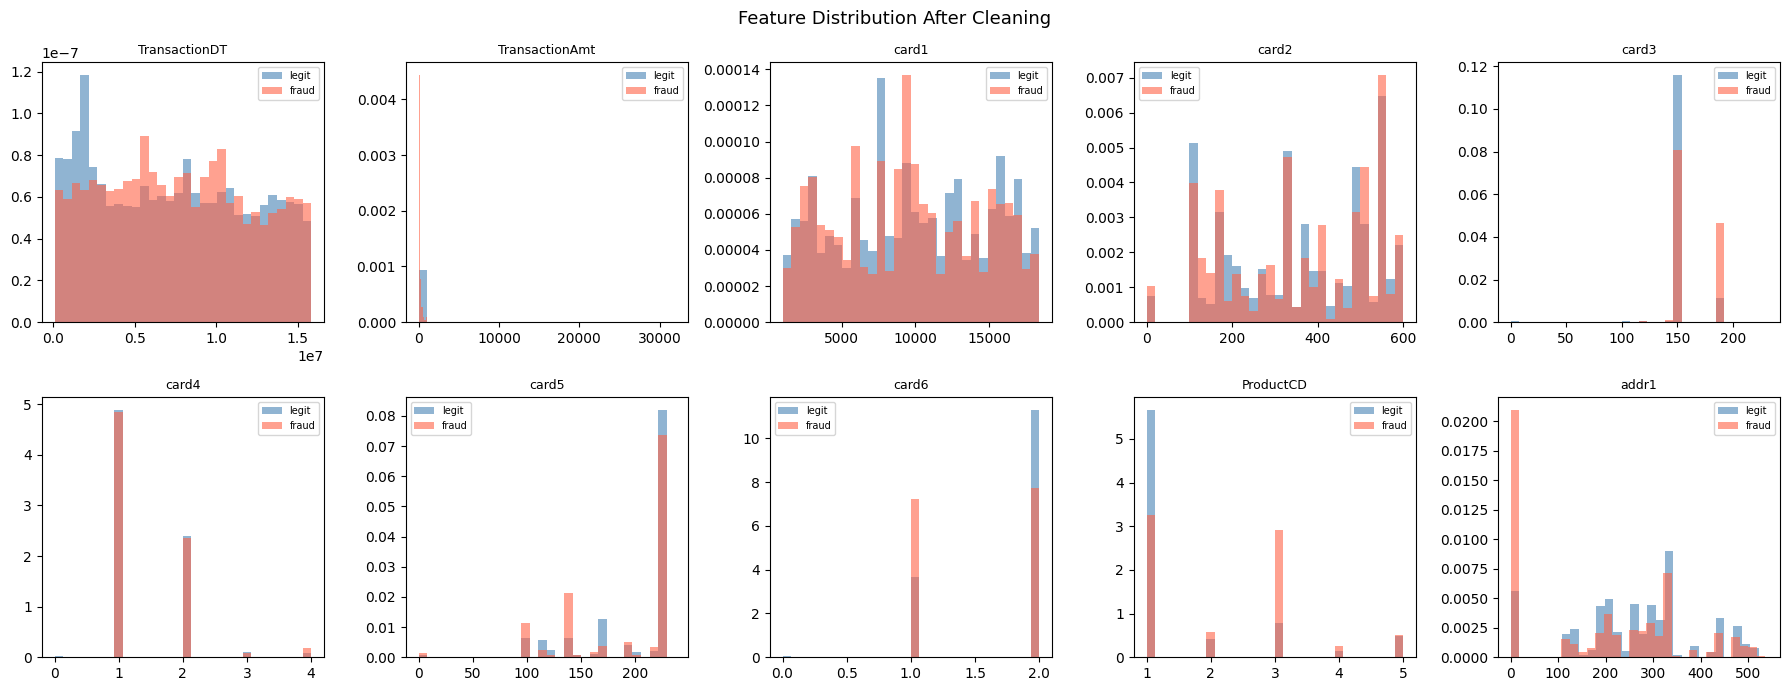

In [20]:
ncs = [c for c in df.columns if c != "isFraud"][:10]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(ncs):
    axes[i].hist(df[df["isFraud"] == 0][col], bins=30, alpha=0.6,
                 color="steelblue", label="legit", density=True)
    axes[i].hist(df[df["isFraud"] == 1][col], bins=30, alpha=0.6,
                 color="tomato", label="fraud", density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle("Feature Distribution After Cleaning", fontsize=13)
plt.tight_layout()
plt.show()

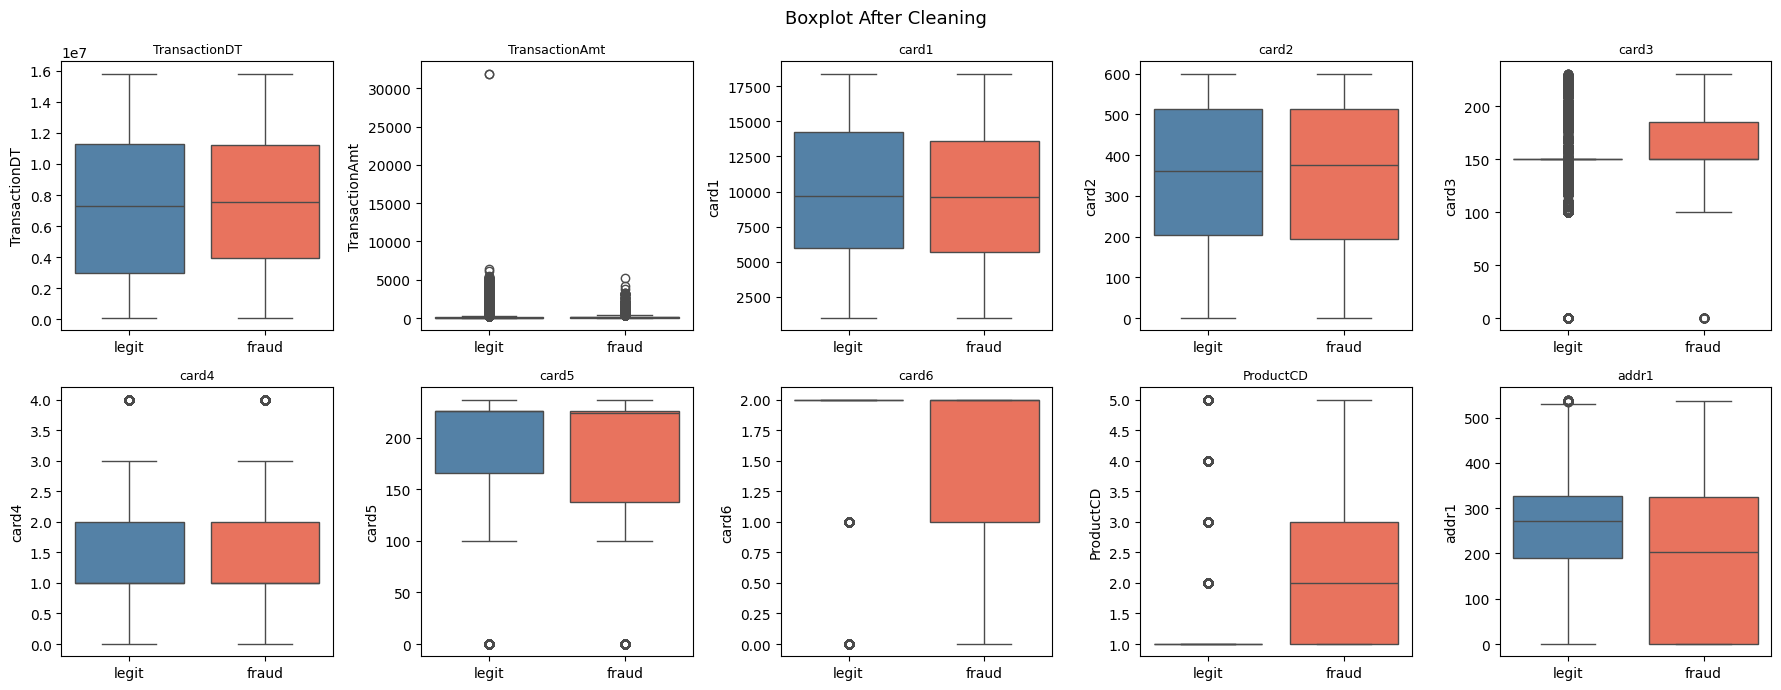

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(ncs):
    tmp = df[[col, "isFraud"]].copy()
    tmp["label"] = tmp["isFraud"].map({0: "legit", 1: "fraud"})
    sns.boxplot(data=tmp, x="label", y=col, ax=axes[i],
                palette={"legit": "steelblue", "fraud": "tomato"})
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel("")

plt.suptitle("Boxplot After Cleaning", fontsize=13)
plt.tight_layout()
plt.show()

R_emaildomain    -0.161815
addr2            -0.161030
card3             0.128035
addr1            -0.106814
ProductCD         0.102132
card6            -0.097674
card5            -0.033430
P_emaildomain    -0.028892
card1            -0.013640
TransactionDT     0.013103
TransactionAmt    0.011320
card4             0.009983
card2             0.000960
Name: isFraud, dtype: float64


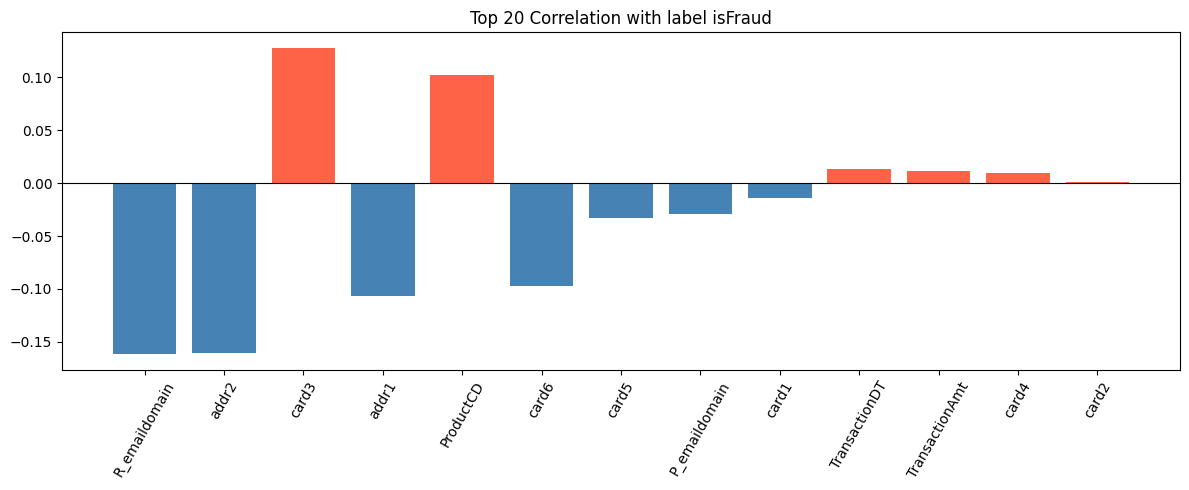

In [22]:
corr_target = df.corr()["isFraud"].drop("isFraud").sort_values(key=abs, ascending=False)
print(corr_target.head(20))

top20 = corr_target.head(20)
plt.figure(figsize=(12, 5))
plt.bar(top20.index, top20.values,
        color=["tomato" if v > 0 else "steelblue" for v in top20.values])
plt.axhline(0, color="black", lw=0.8)
plt.title("Top 20 Correlation with label isFraud")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

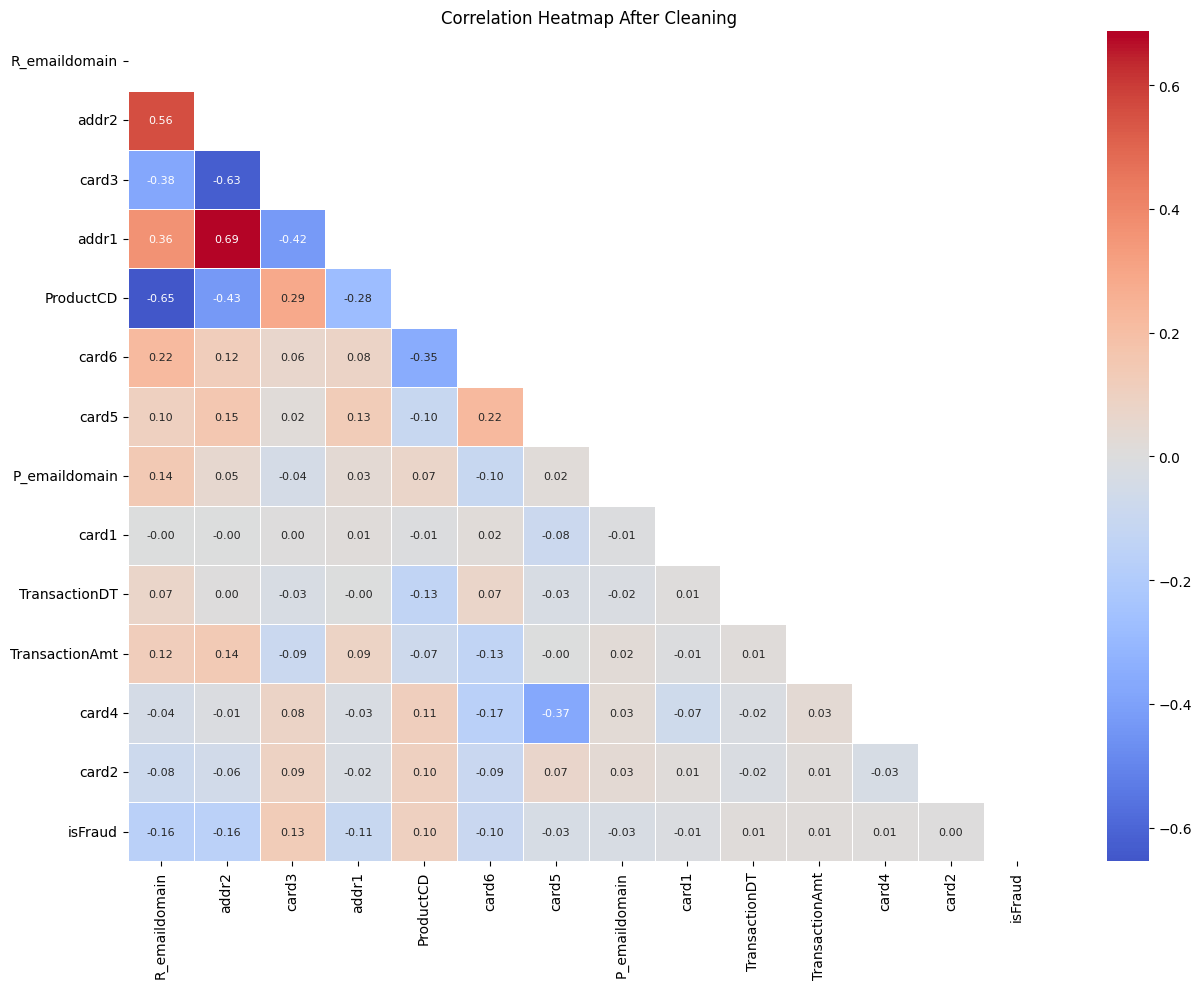

In [23]:
top_feats = corr_target.head(15).index.tolist() + ["isFraud"]

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones(len(top_feats), dtype=bool))
sns.heatmap(df[top_feats].corr(), mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Heatmap After Cleaning")
plt.tight_layout()
plt.show()

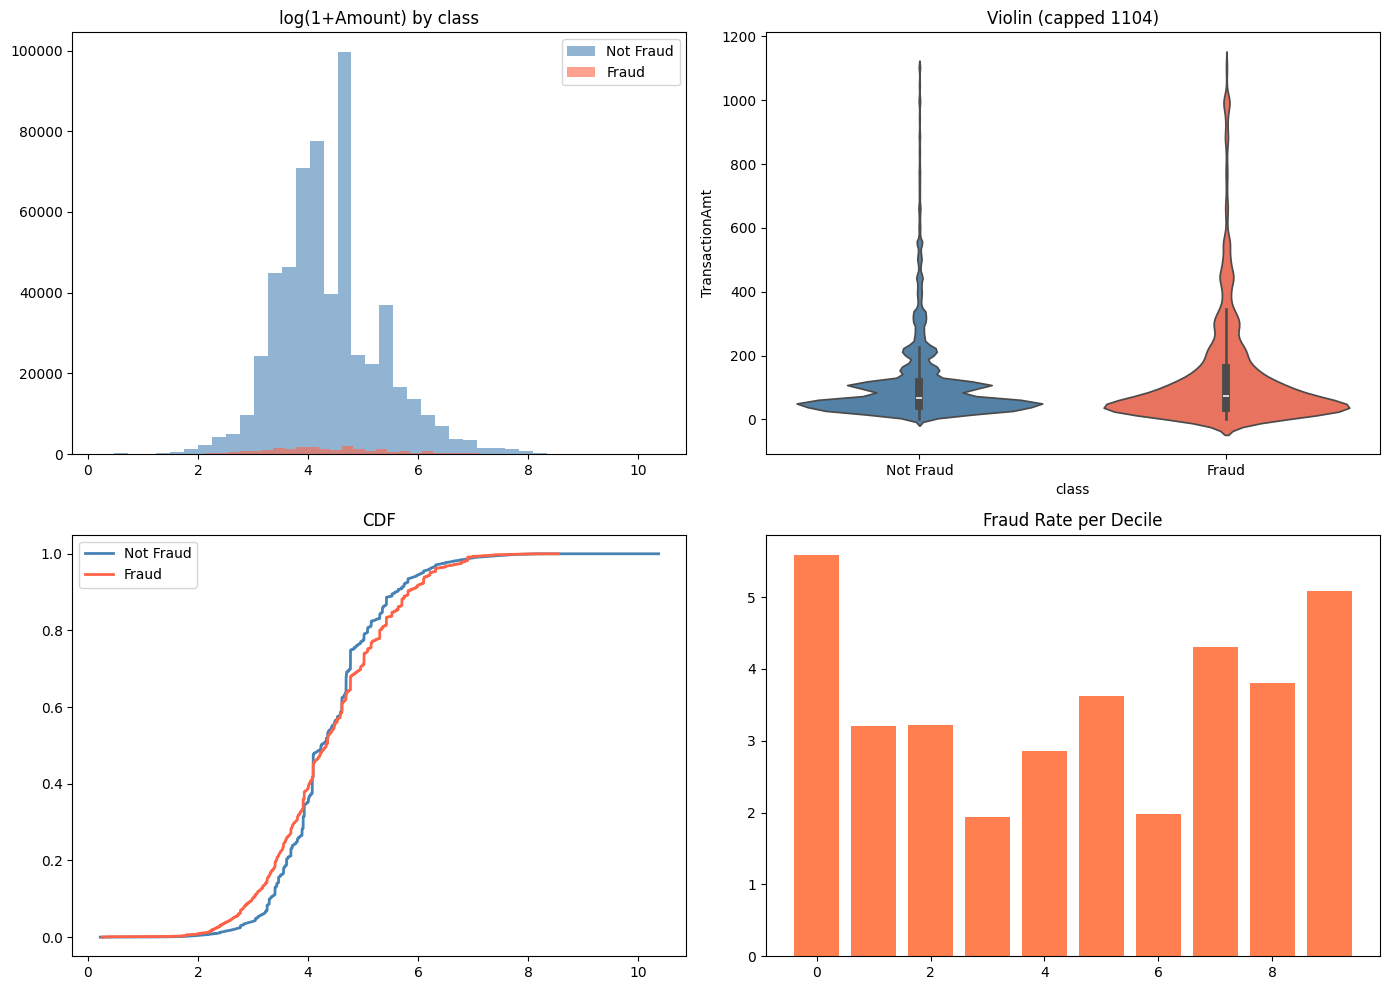

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for lbl, clr, nm in [(0, "steelblue", "Not Fraud"), (1, "tomato", "Fraud")]:
    d = df[df["isFraud"] == lbl]["TransactionAmt"]
    axes[0, 0].hist(np.log1p(d), bins=40, alpha=0.6, color=clr, label=nm)
axes[0, 0].set_title("log(1+Amount) by class")
axes[0, 0].legend()

cap = df["TransactionAmt"].quantile(0.99)
tmp_v = df[df["TransactionAmt"] <= cap].copy()
tmp_v["class"] = tmp_v["isFraud"].map({0: "Not Fraud", 1: "Fraud"})
sns.violinplot(data=tmp_v, x="class", y="TransactionAmt",
               palette={"Not Fraud": "steelblue", "Fraud": "tomato"}, ax=axes[0, 1])
axes[0, 1].set_title(f"Violin (capped {cap:.0f})")

for lbl, clr, nm in [(0, "steelblue", "Not Fraud"), (1, "tomato", "Fraud")]:
    d = np.sort(np.log1p(df[df["isFraud"] == lbl]["TransactionAmt"]))
    axes[1, 0].plot(d, np.arange(1, len(d)+1) / len(d), color=clr, label=nm, lw=2)
axes[1, 0].set_title("CDF")
axes[1, 0].legend()

df["_buck"] = pd.qcut(df["TransactionAmt"], q=10, duplicates="drop", labels=False)
fbuck = df.groupby("_buck")["isFraud"].mean() * 100
axes[1, 1].bar(fbuck.index, fbuck.values, color="coral")
axes[1, 1].set_title("Fraud Rate per Decile")
df.drop(columns=["_buck"], inplace=True)

plt.tight_layout()
plt.show()

TransactionDT     2.131875e+13
card1             2.402147e+07
TransactionAmt    5.719871e+04
card2             2.648036e+04
addr1             1.755786e+04
card5             1.973177e+03
addr2             7.514658e+02
P_emaildomain     2.839993e+02
card3             1.902044e+02
R_emaildomain     1.513056e+02
ProductCD         1.355773e+00
card4             3.366580e-01
card6             1.967934e-01
dtype: float64


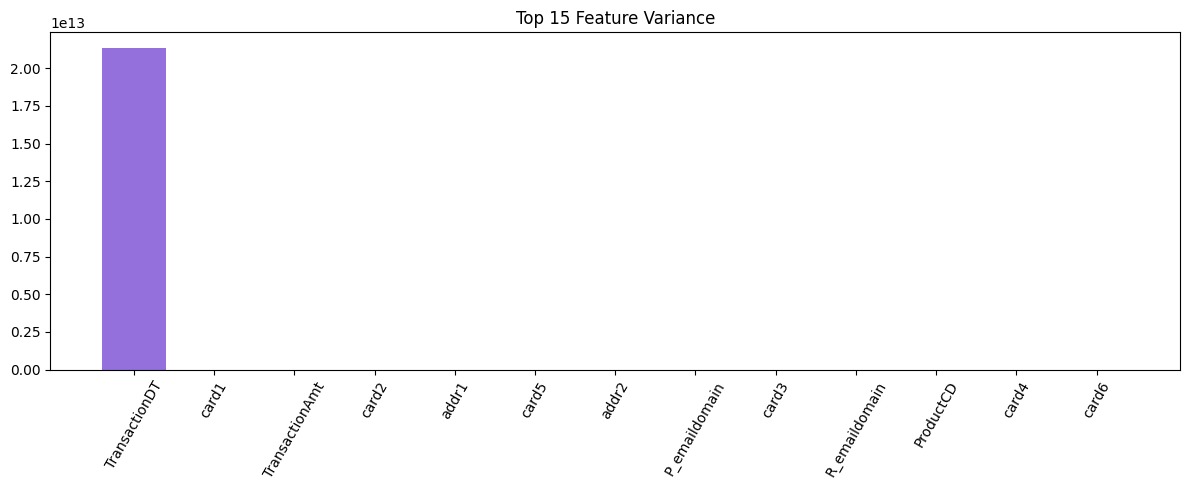

In [25]:
feat_var = df.drop(columns=["isFraud"]).var().sort_values(ascending=False)
print(feat_var.head(15))

plt.figure(figsize=(12, 5))
plt.bar(feat_var.head(15).index, feat_var.head(15).values, color="mediumpurple")
plt.title("Top 15 Feature Variance")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

In [26]:
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"train: {X_train.shape[0]:,} | fraud: {y_train.sum():,}")
print(f"test : {X_test.shape[0]:,} | fraud: {y_test.sum():,}")

train: 472,432 | fraud: 16,530
test : 118,108 | fraud: 4,133


Original features   : 13
PCA components kept : 11  (>= 95 % variance)
Variance explained  : 96.04 %
Train shape after PCA: (472432, 11)
Test  shape after PCA: (118108, 11)


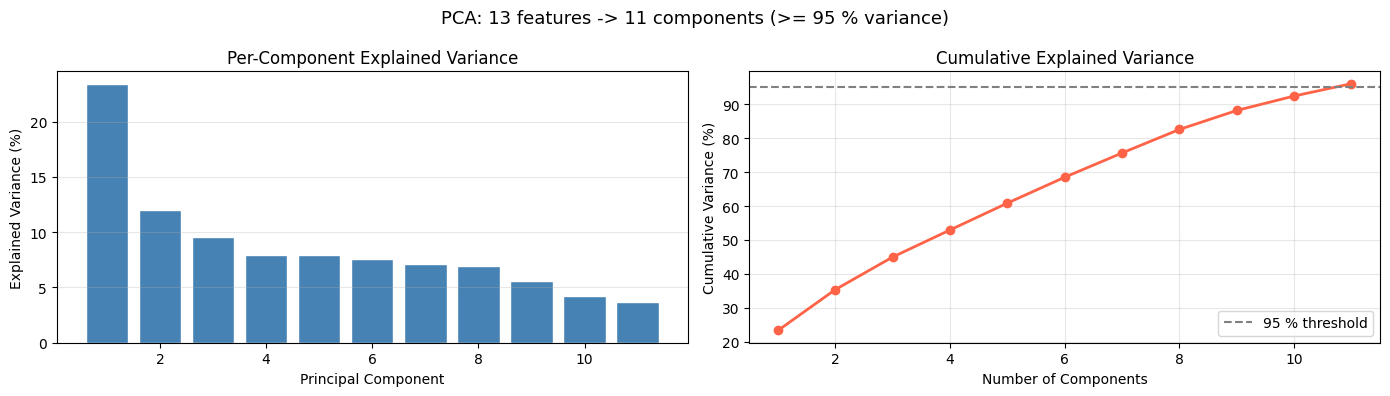

In [27]:
# -- STEP 4b: PCA DIMENSIONALITY REDUCTION ----------------------------------
# Applied after StandardScaler; keeps components that explain >= 95% variance.
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)   # fit on train only
X_test_pca  = pca.transform(X_test_sc)         # apply same transform to test

n_comp = pca.n_components_
print(f'Original features   : {X_train_sc.shape[1]}')
print(f'PCA components kept : {n_comp}  (>= 95 % variance)')
print(f'Variance explained  : {pca.explained_variance_ratio_.sum()*100:.2f} %')
print(f'Train shape after PCA: {X_train_pca.shape}')
print(f'Test  shape after PCA: {X_test_pca.shape}')

# -- Explained-variance bar + cumulative curve --------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(1, n_comp+1),
            pca.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Per-Component Explained Variance')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(range(1, n_comp+1),
             np.cumsum(pca.explained_variance_ratio_) * 100,
             marker='o', color='tomato', lw=2)
axes[1].axhline(95, color='grey', ls='--', lw=1.5, label='95 % threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'PCA: 13 features -> {n_comp} components (>= 95 % variance)', fontsize=13)
plt.tight_layout()
plt.show()


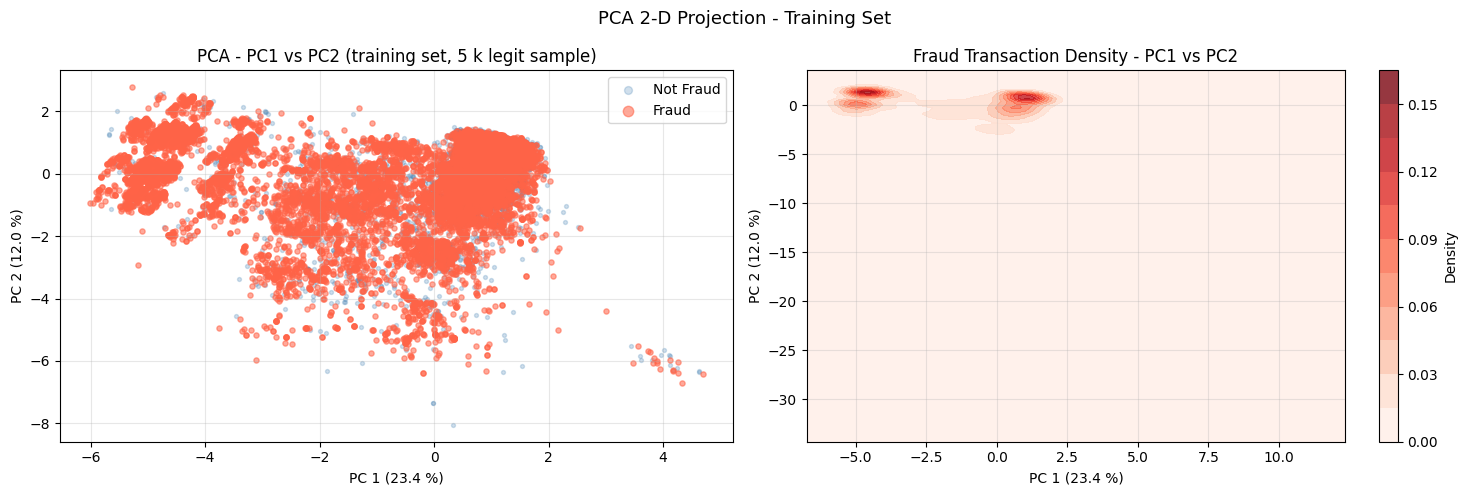

In [28]:
# -- PCA 2-D VISUALISATION ----------------------------------------------------
# Project training set onto PC1 & PC2 for a fraud vs. legit scatter plot.
# (A separate 2-component PCA is used only for this plot.)
from scipy.stats import gaussian_kde

pca2d        = PCA(n_components=2, random_state=42)
X_train_2d   = pca2d.fit_transform(X_train_sc)

fraud_mask   = y_train.values == 1
legit_mask   = y_train.values == 0

# Sub-sample legit points so fraud dots are visible
rng       = np.random.default_rng(42)
legit_idx = rng.choice(np.where(legit_mask)[0],
                        size=min(5_000, int(legit_mask.sum())),
                        replace=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: scatter
axes[0].scatter(X_train_2d[legit_idx, 0], X_train_2d[legit_idx, 1],
                c='steelblue', alpha=0.25, s=8, label='Not Fraud')
axes[0].scatter(X_train_2d[fraud_mask, 0], X_train_2d[fraud_mask, 1],
                c='tomato', alpha=0.55, s=14, label='Fraud')
axes[0].set_title('PCA - PC1 vs PC2 (training set, 5 k legit sample)')
axes[0].set_xlabel(f'PC 1 ({pca2d.explained_variance_ratio_[0]*100:.1f} %)')
axes[0].set_ylabel(f'PC 2 ({pca2d.explained_variance_ratio_[1]*100:.1f} %)')
axes[0].legend(markerscale=2)
axes[0].grid(alpha=0.3)

# Right: KDE density of fraud cluster
fraud_pts = X_train_2d[fraud_mask]
xmin, xmax = X_train_2d[:, 0].min(), X_train_2d[:, 0].max()
ymin, ymax = X_train_2d[:, 1].min(), X_train_2d[:, 1].max()
xg = np.linspace(xmin, xmax, 120)
yg = np.linspace(ymin, ymax, 120)
XX, YY = np.meshgrid(xg, yg)
kde = gaussian_kde(fraud_pts.T)
ZZ  = kde(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)
cf  = axes[1].contourf(XX, YY, ZZ, levels=14, cmap='Reds', alpha=0.8)
fig.colorbar(cf, ax=axes[1], label='Density')
axes[1].set_title('Fraud Transaction Density - PC1 vs PC2')
axes[1].set_xlabel(f'PC 1 ({pca2d.explained_variance_ratio_[0]*100:.1f} %)')
axes[1].set_ylabel(f'PC 2 ({pca2d.explained_variance_ratio_[1]*100:.1f} %)')
axes[1].grid(alpha=0.3)

plt.suptitle('PCA 2-D Projection - Training Set', fontsize=13)
plt.tight_layout()
plt.show()


In [29]:
# -- STEP 5: ISOLATION FOREST TRAINING (on PCA-reduced features) -------------
contamination = float(df['isFraud'].mean())
print(f'Observed fraud rate (contamination): {contamination:.5f}  '
      f'(~ {contamination*100:.2f} %)')
print(f'Training on {X_train_pca.shape[1]} PCA components '
      f'(from {X_train_sc.shape[1]} original features)')

t0 = time.time()

model = IsolationForest(
    n_estimators=300,
    contamination=contamination,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train_pca)
print(f'Training complete  ({time.time() - t0:.1f}s)')


Observed fraud rate (contamination): 0.03499  (~ 3.50 %)
Training on 11 PCA components (from 13 original features)
Training complete  (7.6s)


In [30]:
y_pred_raw = model.predict(X_test_pca)
y_pred = np.where(y_pred_raw == -1, 1, 0)   # -1 = anomaly = fraud

raw_scores = model.score_samples(X_test_pca)  # higher = more normal
y_score    = -raw_scores                       # negate: higher = more anomalous
y_prob     = (y_score - y_score.min()) / (y_score.max() - y_score.min())

print(f'Flagged as fraud : {y_pred.sum():,}')
print(f'Actual fraud     : {y_test.sum():,}')


Flagged as fraud : 4,099
Actual fraud     : 4,133


In [31]:
print(classification_report(y_test, y_pred, target_names=["Not Fraud", "Fraud"]))

roc = roc_auc_score(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)

print(f"ROC-AUC   : {roc:.4f}")
print(f"Avg PRC   : {ap:.4f}")
print(f"F1        : {f1:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")

              precision    recall  f1-score   support

   Not Fraud       0.97      0.97      0.97    113975
       Fraud       0.06      0.06      0.06      4133

    accuracy                           0.93    118108
   macro avg       0.51      0.51      0.51    118108
weighted avg       0.93      0.93      0.93    118108

ROC-AUC   : 0.6769
Avg PRC   : 0.0615
F1        : 0.0598
Precision : 0.0600
Recall    : 0.0595


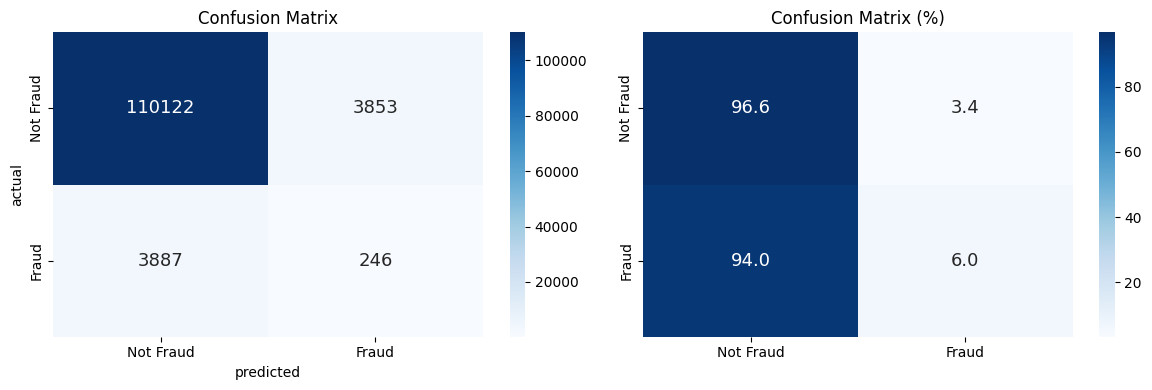

TPR: 5.95%
FPR: 3.38%


In [32]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt="d", ax=axes[0], cmap="Blues",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"],
            annot_kws={"size": 13})
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("predicted")
axes[0].set_ylabel("actual")

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt=".1f", ax=axes[1], cmap="Blues",
            xticklabels=["Not Fraud", "Fraud"],
            yticklabels=["Not Fraud", "Fraud"],
            annot_kws={"size": 13})
axes[1].set_title("Confusion Matrix (%)")

plt.tight_layout()
plt.show()

print(f"TPR: {tp/(tp+fn)*100:.2f}%")
print(f"FPR: {fp/(fp+tn)*100:.2f}%")

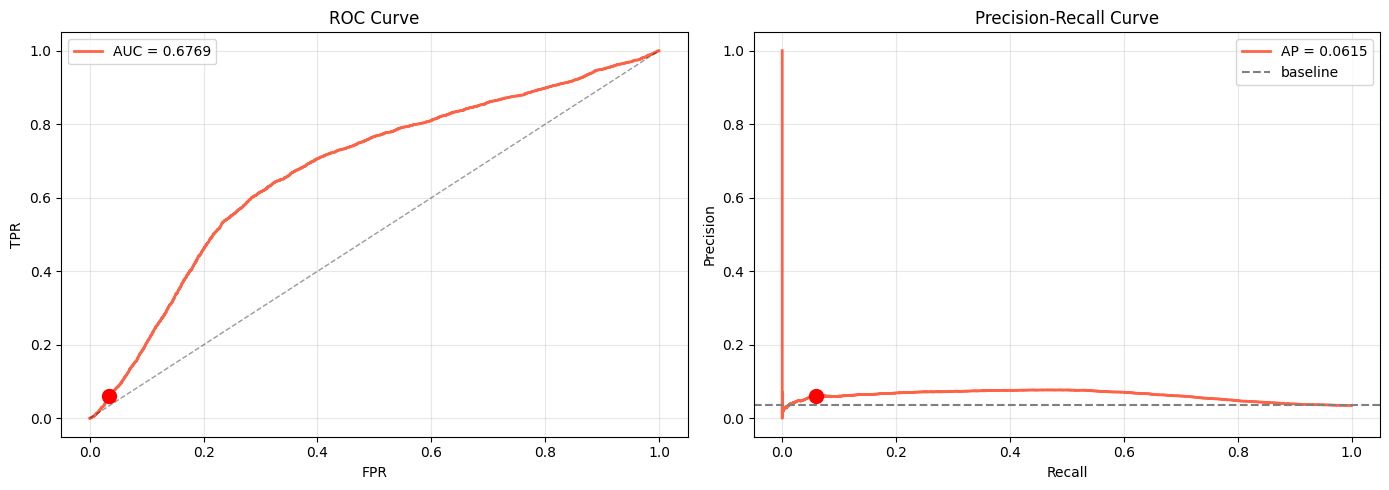

In [33]:
fpr_arr, tpr_arr, _ = roc_curve(y_test, y_prob)
prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr_arr, tpr_arr, color="tomato", lw=2, label=f"AUC = {roc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
axes[0].scatter([fp/(fp+tn)], [tp/(tp+fn)], s=100, color="red", zorder=5)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rec_arr, prec_arr, color="tomato", lw=2, label=f"AP = {ap:.4f}")
axes[1].axhline(y=y_test.mean(), color="grey", ls="--", lw=1.5, label="baseline")
axes[1].scatter([rec], [prec], s=100, color="red", zorder=5)
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

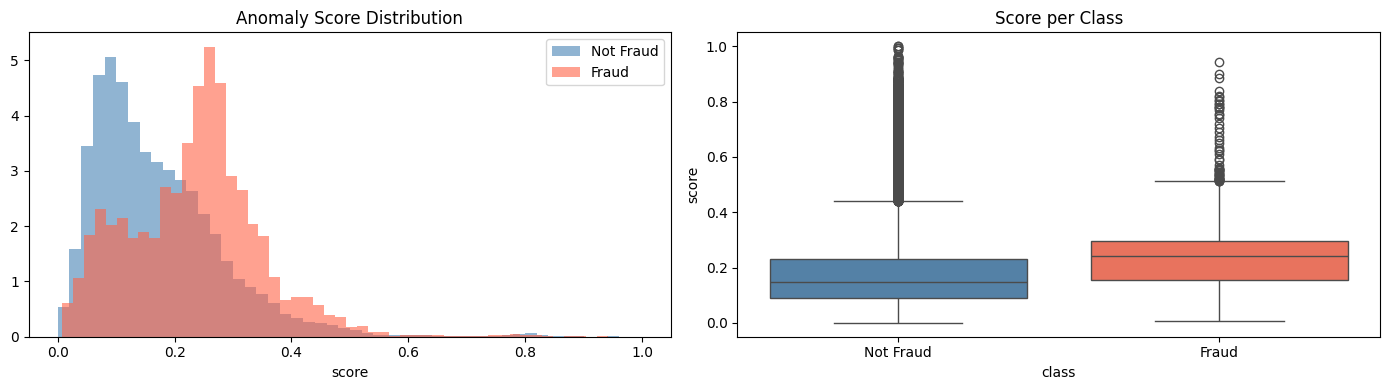

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for lbl, clr, nm in [(0, "steelblue", "Not Fraud"), (1, "tomato", "Fraud")]:
    mask = (y_test == lbl).values
    axes[0].hist(y_prob[mask], bins=50, alpha=0.6, color=clr, label=nm, density=True)
axes[0].set_title("Anomaly Score Distribution")
axes[0].set_xlabel("score")
axes[0].legend()

score_df = pd.DataFrame({"score": y_prob,
                          "class": y_test.map({0: "Not Fraud", 1: "Fraud"}).values})
sns.boxplot(data=score_df, x="class", y="score", ax=axes[1],
            palette={"Not Fraud": "steelblue", "Fraud": "tomato"})
axes[1].set_title("Score per Class")

plt.tight_layout()
plt.show()

 threshold  precision   recall       f1  flagged
      0.10   0.042843 0.854585 0.081595    82441
      0.15   0.053332 0.758529 0.099657    58783
      0.20   0.065923 0.646262 0.119642    40517
      0.25   0.077116 0.461892 0.132166    24755
      0.30   0.071659 0.241471 0.110520    13927
      0.35   0.063073 0.123155 0.083422     8070
      0.40   0.060303 0.068473 0.064129     4693
      0.45   0.047921 0.032906 0.039019     2838
      0.50   0.039216 0.015485 0.022203     1632
      0.55   0.032462 0.008710 0.013735     1109
      0.60   0.030067 0.006533 0.010733      898
      0.65   0.029101 0.005323 0.009000      756
      0.70   0.028571 0.004597 0.007920      665
      0.75   0.029038 0.003871 0.006832      551
      0.80   0.021858 0.001936 0.003556      366
      0.85   0.032258 0.000726 0.001420       93
      0.90   0.057143 0.000484 0.000960       35

best threshold (F1): 0.25


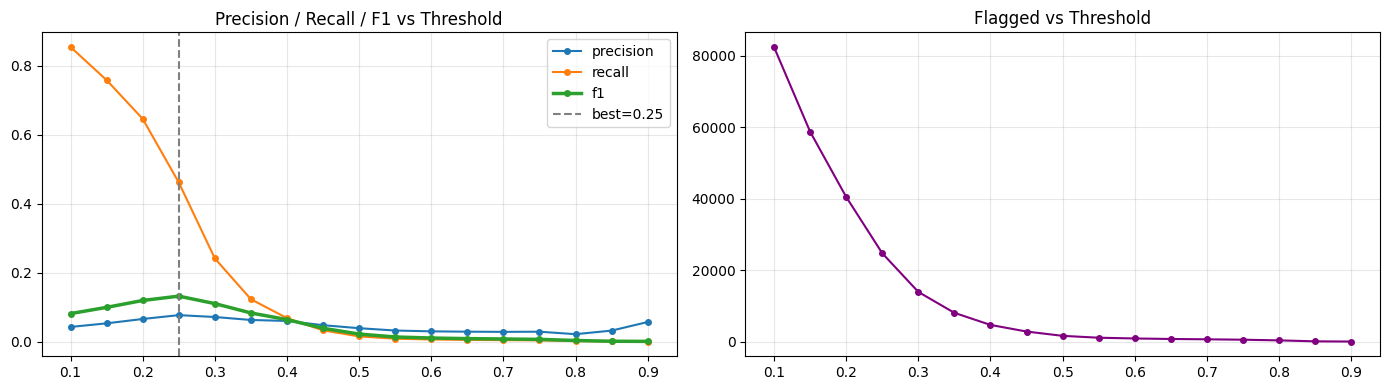

In [35]:
rows = []
for thr in np.arange(0.1, 0.95, 0.05):
    yp = (y_prob >= thr).astype(int)
    rows.append({
        "threshold": round(thr, 2),
        "precision": precision_score(y_test, yp, zero_division=0),
        "recall": recall_score(y_test, yp),
        "f1": f1_score(y_test, yp),
        "flagged": yp.sum()
    })

thr_df = pd.DataFrame(rows)
best_thr = thr_df.loc[thr_df["f1"].idxmax(), "threshold"]
print(thr_df.to_string(index=False))
print(f"\nbest threshold (F1): {best_thr}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(thr_df["threshold"], thr_df["precision"], label="precision", marker="o", ms=4)
axes[0].plot(thr_df["threshold"], thr_df["recall"], label="recall", marker="o", ms=4)
axes[0].plot(thr_df["threshold"], thr_df["f1"], label="f1", marker="o", ms=4, lw=2.5)
axes[0].axvline(best_thr, color="grey", ls="--", label=f"best={best_thr}")
axes[0].set_title("Precision / Recall / F1 vs Threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(thr_df["threshold"], thr_df["flagged"], color="purple", marker="o", ms=4)
axes[1].set_title("Flagged vs Threshold")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

PC2     0.609097
PC1     0.470909
PC7     0.216446
PC6     0.181872
PC8     0.131101
PC10    0.116182
PC3     0.095912
PC4     0.095776
PC5     0.086181
PC11    0.050523
PC9     0.001044
dtype: float64


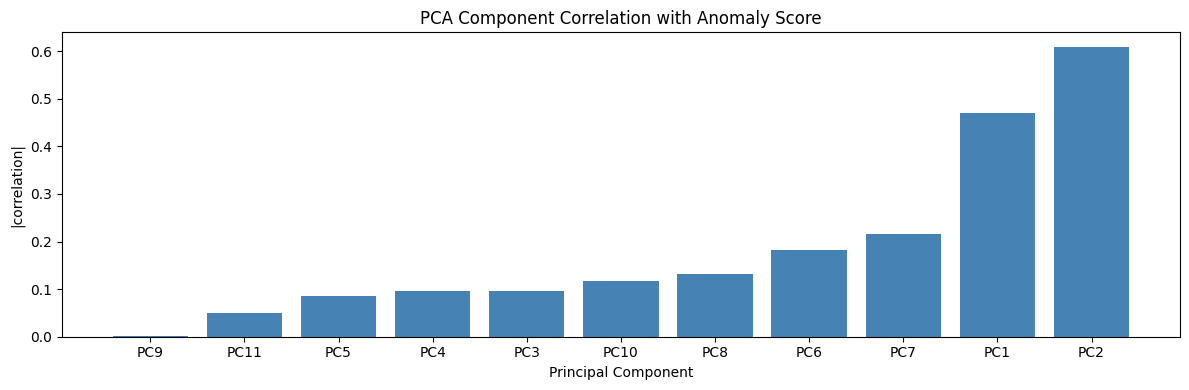

In [36]:
# Correlation of each PCA component with the anomaly score
pc_labels = [f'PC{i+1}' for i in range(X_test_pca.shape[1])]

feat_imp = pd.Series(
    [abs(np.corrcoef(X_test_pca[:, i], y_score)[0, 1])
     for i in range(X_test_pca.shape[1])],
    index=pc_labels
).sort_values(ascending=False)

print(feat_imp)

plt.figure(figsize=(12, 4))
plt.bar(feat_imp.index[::-1], feat_imp.values[::-1], color='steelblue')
plt.title('PCA Component Correlation with Anomaly Score')
plt.xlabel('Principal Component')
plt.ylabel('|correlation|')
plt.tight_layout()
plt.show()


In [37]:
with open('isolation_forest.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('pca.pkl', 'wb') as f:
    pickle.dump(pca, f)

print('Saved:')
print('  isolation_forest.pkl  - trained Isolation Forest')
print('  scaler.pkl            - fitted StandardScaler (13 features)')
print('  pca.pkl               - fitted PCA transformer')
print(f'\nInference pipeline: raw 13 features -> scaler -> pca -> model')


Saved:
  isolation_forest.pkl  - trained Isolation Forest
  scaler.pkl            - fitted StandardScaler (13 features)
  pca.pkl               - fitted PCA transformer

Inference pipeline: raw 13 features -> scaler -> pca -> model
